## Loan Prediction Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('loan_data.csv')
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


## Data Exploration and Preprocessing

In [2]:
df.info()
print('\nMissing Values:')
print(df.isnull().sum())
print('\nBasic Statistics:')
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB

Missing Values:
credit.policy        0
purpose              0


,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9.578000e+03,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000
mean,0.804970,0.122640,319.089413,10.932117,12.606679,710.846314,4560.767197,1.691396e+04,46.799236,1.577469,0.163708,0.062122,0.160054
std,0.396245,0.026847,207.071301,0.614813,6.883970,37.970537,2496.930377,3.375619e+04,29.014417,2.200245,0.546215,0.262126,0.366676
min,0.000000,0.060000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.103900,163.770000,10.558414,7.212500,682.000000,2820.000000,3.187000e+03,22.600000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.122100,268.950000,10.928884,12.665000,707.000000,4139.958333,8.596000e+03,46.300000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.140700,432.762500,11.291293,17.950000,737.000000,5730.000000,1.824950e+04,70.900000,2.000000,0.000000,0.000000,0.000000
max,1.000000,0.216400,940.140000,14.528354,29.960000,827.000000,17639.958330,1.207359e+06,119.000000,33.000000,13.000000,5.000000,1.000000


In [ ]:
print("\nDataFrame Columns:")
print(df.columns.tolist())

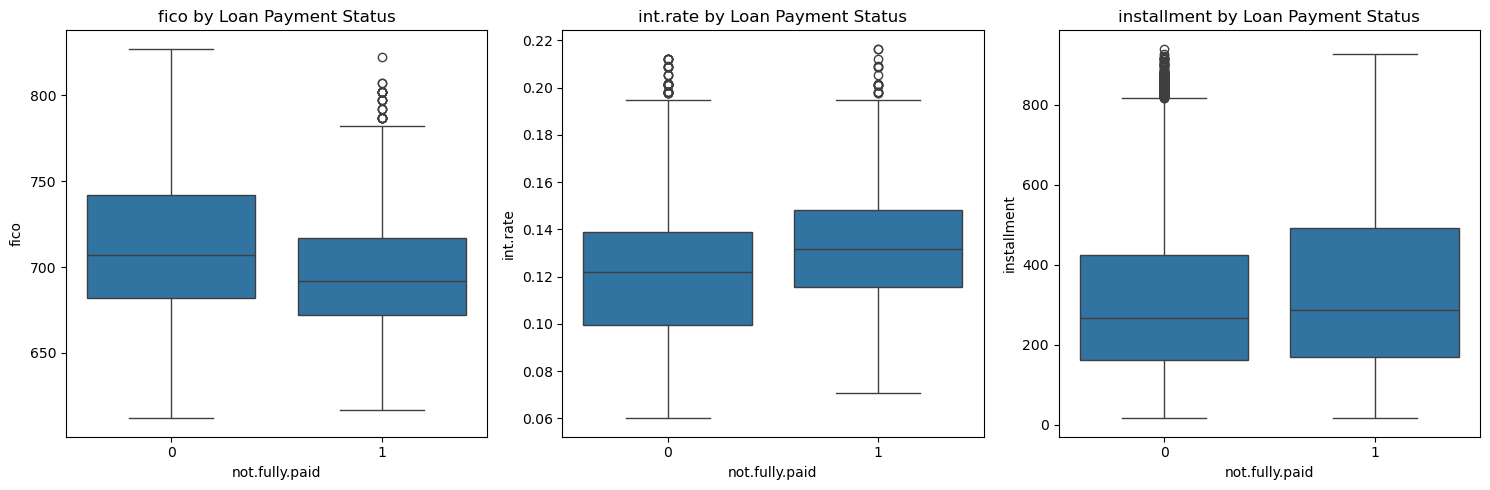

In [5]:
categorical_cols = ['credit.policy', 'purpose', 'not.fully.paid']
numeric_cols = ['int.rate', 'installment', 'log.annual.inc', 'dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util', 'inq.last.6mths', 'delinq.2yrs', 'pub.rec']

plt.figure(figsize=(15, 5))
for i, col in enumerate(['fico', 'int.rate', 'installment']):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x='not.fully.paid', y=col, data=df)
    plt.title(f'{col} by Loan Payment Status')
plt.tight_layout()
plt.show()

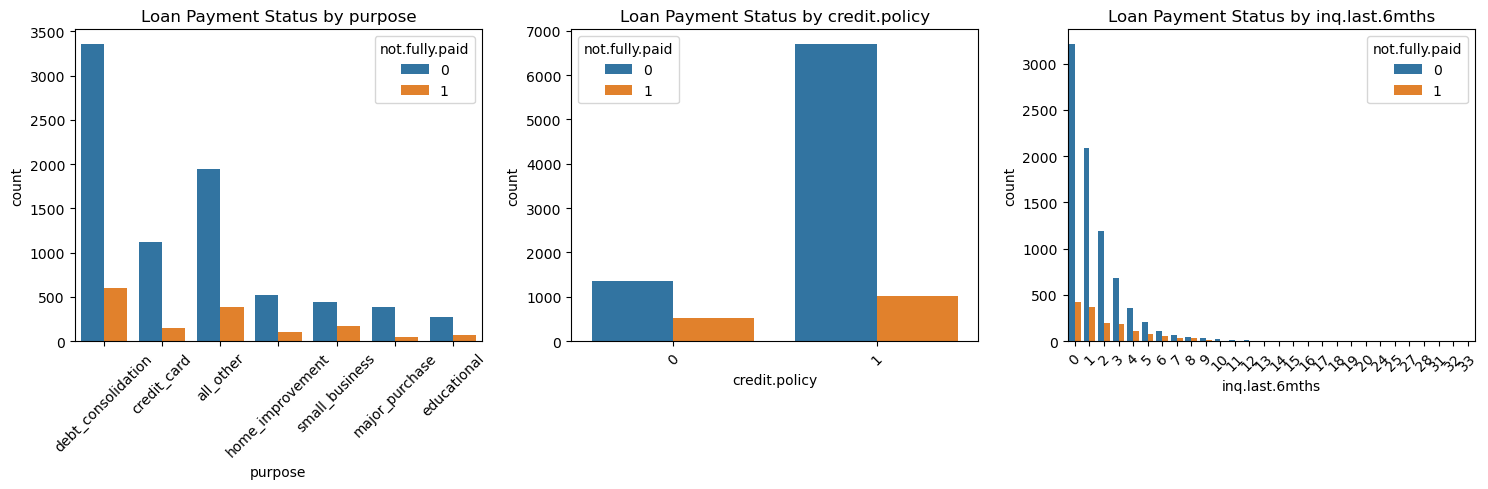

In [6]:
plt.figure(figsize=(15, 5))
for i, col in enumerate(['purpose', 'credit.policy', 'inq.last.6mths']):
    plt.subplot(1, 3, i+1)
    sns.countplot(data=df, x=col, hue='not.fully.paid')
    plt.title(f'Loan Payment Status by {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
# No need for log transformation of annual income as it's already logged in the dataset
# Fill missing values if any
for col in numeric_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

# Handle categorical variables
for col in categorical_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)
    if col == 'purpose':  # Only encode 'purpose' as other categoricals are binary
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])

## Decision Tree Analysis

Decision Tree Initial Performance:

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1611
           1       0.22      0.24      0.23       305

    accuracy                           0.75      1916
   macro avg       0.54      0.54      0.54      1916
weighted avg       0.75      0.75      0.75      1916



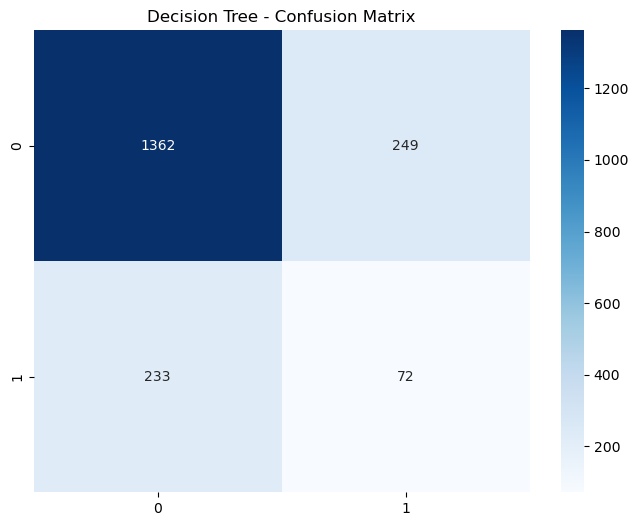

In [10]:
X = df.drop('not.fully.paid', axis=1)
y = df['not.fully.paid']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)

dt_predictions = dtree.predict(X_test)

print("Decision Tree Initial Performance:")
print("\nClassification Report:")
print(classification_report(y_test, dt_predictions))

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, dt_predictions), annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree - Confusion Matrix')
plt.show()

In [11]:
dt_param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_param_grid, cv=5)
dt_grid.fit(X_train, y_train)

print("Decision Tree Grid Search Results:")
print(f"Best parameters: {dt_grid.best_params_}")
print(f"Best cross-validation score: {dt_grid.best_score_:.4f}")

dt_best = dt_grid.best_estimator_
dt_final_pred = dt_best.predict(X_test)

print("\nTuned Decision Tree Performance:")
print("\nClassification Report:")
print(classification_report(y_test, dt_final_pred))

Decision Tree Grid Search Results:
Best parameters: {'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best cross-validation score: 0.8384

Tuned Decision Tree Performance:

Classification Report:
              precision    recall  f1-score   support

           0       0.84      1.00      0.91      1611
           1       0.14      0.00      0.01       305

    accuracy                           0.84      1916
   macro avg       0.49      0.50      0.46      1916
weighted avg       0.73      0.84      0.77      1916



## Random Forest Analysis

Random Forest Initial Performance:

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.99      0.91      1611
           1       0.40      0.02      0.04       305

    accuracy                           0.84      1916
   macro avg       0.62      0.51      0.47      1916
weighted avg       0.77      0.84      0.77      1916



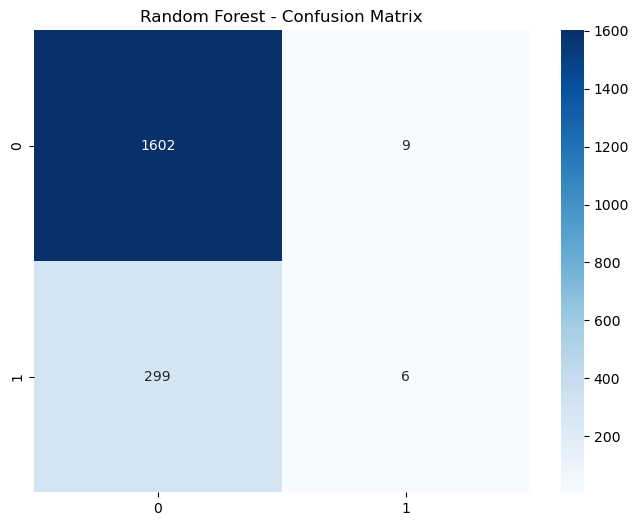

In [12]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_predictions = rf.predict(X_test)

print("Random Forest Initial Performance:")
print("\nClassification Report:")
print(classification_report(y_test, rf_predictions))

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, rf_predictions), annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest - Confusion Matrix')
plt.show()

In [13]:
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_param_grid, cv=5)
rf_grid.fit(X_train, y_train)

print("Random Forest Grid Search Results:")
print(f"Best parameters: {rf_grid.best_params_}")
print(f"Best cross-validation score: {rf_grid.best_score_:.4f}")

rf_best = rf_grid.best_estimator_
rf_final_pred = rf_best.predict(X_test)

print("\nTuned Random Forest Performance:")
print("\nClassification Report:")
print(classification_report(y_test, rf_final_pred))

Random Forest Grid Search Results:
Best parameters: {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
Best cross-validation score: 0.8399

Tuned Random Forest Performance:

Classification Report:
              precision    recall  f1-score   support

           0       0.84      1.00      0.91      1611
           1       0.25      0.00      0.01       305

    accuracy                           0.84      1916
   macro avg       0.55      0.50      0.46      1916
weighted avg       0.75      0.84      0.77      1916



## Model Comparison and Feature Importance

In [14]:
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Decision Tree': [
        classification_report(y_test, dt_final_pred, output_dict=True)['accuracy'],
        classification_report(y_test, dt_final_pred, output_dict=True)['weighted avg']['precision'],
        classification_report(y_test, dt_final_pred, output_dict=True)['weighted avg']['recall'],
        classification_report(y_test, dt_final_pred, output_dict=True)['weighted avg']['f1-score']
    ],
    'Random Forest': [
        classification_report(y_test, rf_final_pred, output_dict=True)['accuracy'],
        classification_report(y_test, rf_final_pred, output_dict=True)['weighted avg']['precision'],
        classification_report(y_test, rf_final_pred, output_dict=True)['weighted avg']['recall'],
        classification_report(y_test, rf_final_pred, output_dict=True)['weighted avg']['f1-score']
    ]
})

print("Model Performance Comparison:")
print(comparison_df.round(4))

Model Performance Comparison:
      Metric  Decision Tree  Random Forest
0   Accuracy         0.8382         0.8398
1  Precision         0.7297         0.7469
2     Recall         0.8382         0.8398
3   F1-Score         0.7678         0.7686


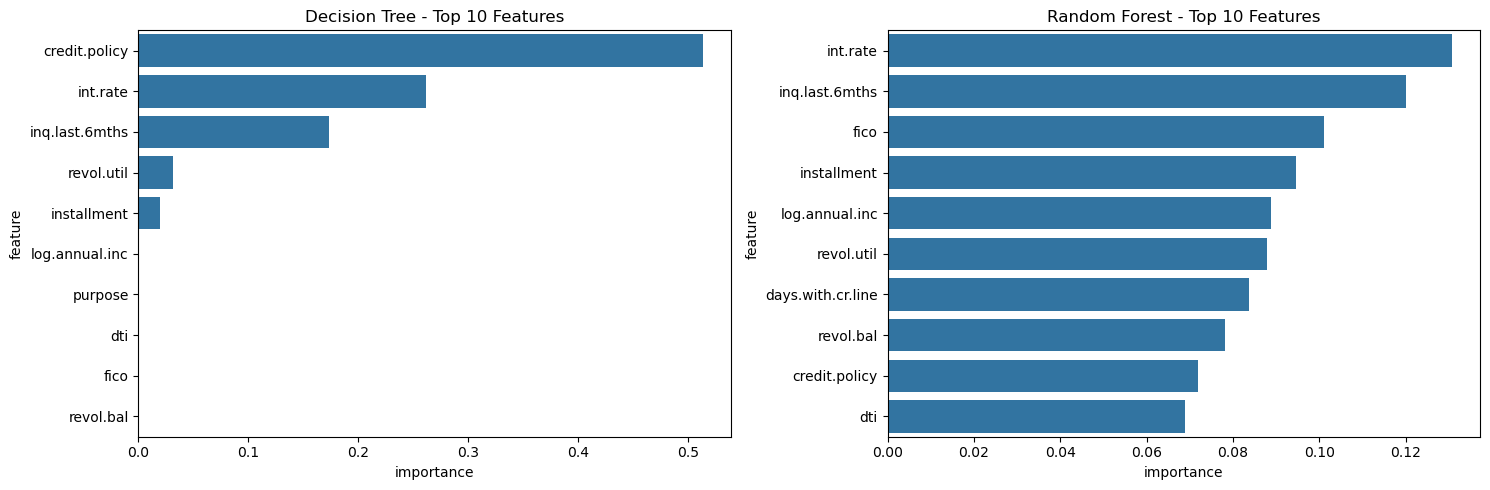

In [15]:
feature_importance_dt = pd.DataFrame({
    'feature': X.columns,
    'importance': dt_best.feature_importances_
}).sort_values('importance', ascending=False)

feature_importance_rf = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_best.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(15,5))

plt.subplot(1, 2, 1)
sns.barplot(x='importance', y='feature', data=feature_importance_dt.head(10))
plt.title('Decision Tree - Top 10 Features')

plt.subplot(1, 2, 2)
sns.barplot(x='importance', y='feature', data=feature_importance_rf.head(10))
plt.title('Random Forest - Top 10 Features')

plt.tight_layout()
plt.show()